In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

df = pd.read_csv('dados_passagens_limpo.csv', sep=';')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   compra_id            497 non-null    str    
 1   quantidade_assentos  497 non-null    int64  
 2   posicoes_assentos    467 non-null    str    
 3   origem               497 non-null    str    
 4   destino              497 non-null    str    
 5   preco_unitario       497 non-null    float64
 6   data_partida         497 non-null    str    
 7   receita              497 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 31.2 KB


In [2]:
df['data_partida'] = pd.to_datetime(df['data_partida'])
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   compra_id            497 non-null    str           
 1   quantidade_assentos  497 non-null    int64         
 2   posicoes_assentos    467 non-null    str           
 3   origem               497 non-null    str           
 4   destino              497 non-null    str           
 5   preco_unitario       497 non-null    float64       
 6   data_partida         497 non-null    datetime64[us]
 7   receita              497 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 31.2 KB


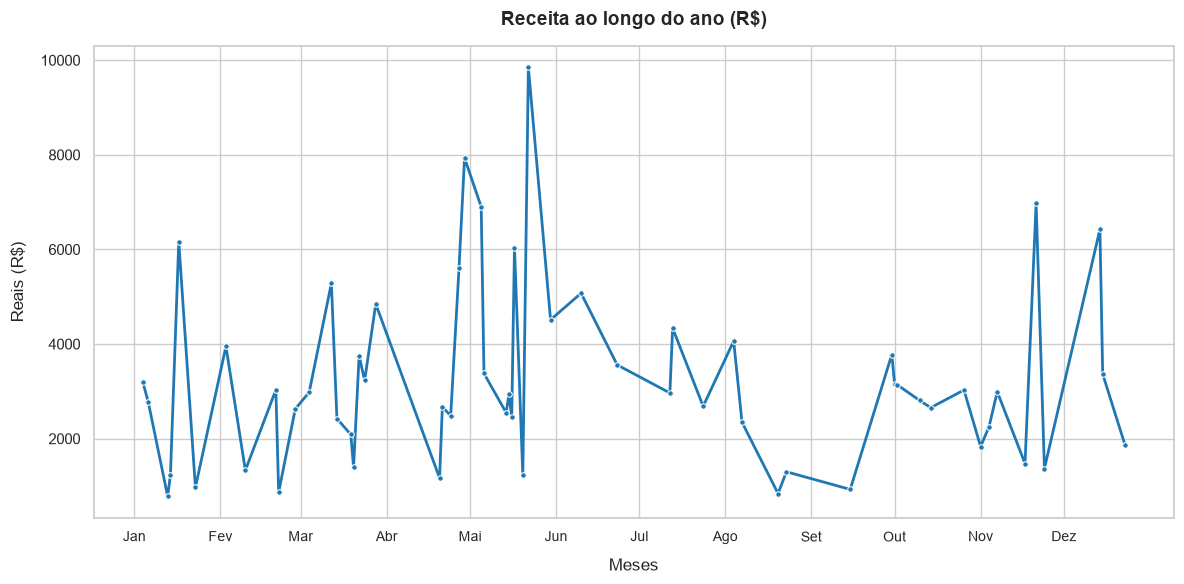

In [3]:
# Configuração de estilo do Seaborn
sns.set_theme(style='whitegrid')

# Agrupa a receita total por data de partida
df_diario = (
    df.groupby(df['data_partida'].dt.date)['receita']
    .sum()
    .reset_index()
)

df_diario['data_partida'] = pd.to_datetime(df_diario['data_partida'])

plt.figure(figsize=(12, 6))

# Gráfico de linha
ax = sns.lineplot(
    data=df_diario,
    x='data_partida',
    y='receita',
    color='#1f77b4',
    linewidth=2,
    marker='o',
    markersize=4,
)

# Títulos e Rótulos
plt.title('Receita ao longo do ano (R$)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Meses', fontsize=12, labelpad=10)
plt.ylabel('Reais (R$)', fontsize=12, labelpad=10)

# Define a marcação no início de cada mês do ano presente nos dados
meses_ticks = pd.date_range(
    start=f"{df_diario['data_partida'].dt.year.min()}-01-01",
    end=f"{df_diario['data_partida'].dt.year.max()}-12-31",
    freq='MS',
)
nomes_meses = [
    'Jan',
    'Fev',
    'Mar',
    'Abr',
    'Mai',
    'Jun',
    'Jul',
    'Ago',
    'Set',
    'Out',
    'Nov',
    'Dez',
]

plt.xticks(
    ticks=meses_ticks,
    labels=nomes_meses[: len(meses_ticks)],
    rotation=0,
    fontsize=10,
)

plt.tight_layout()

# Exibe o gráfico
plt.show()

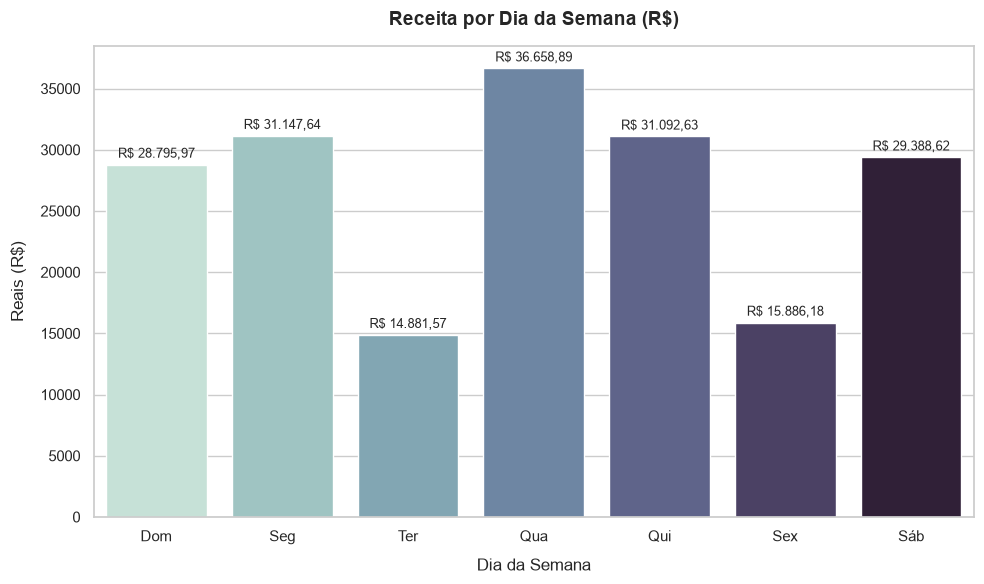

In [4]:
sns.set_theme(style='whitegrid')

# Cria a coluna auxiliar 'dia_semana' (0 = Segunda, ..., 6 = Domingo no Pandas)
df['num_dia_semana'] = df['data_partida'].dt.dayofweek

df['dia_ordem'] = df['num_dia_semana'].apply(lambda x: (x + 1) % 7)

# Agrupa a receita por dia da semana
df_semana = (
    df.groupby('dia_ordem')['receita']
    .sum()
    .reset_index()
)

# Nomes dos dias da semana
dias_nomes = ['Dom', 'Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb']
df_semana['dia_nome'] = df_semana['dia_ordem'].map(lambda x: dias_nomes[x])

# Geração de cores usando a paleta cubehelix
cores = sns.cubehelix_palette(n_colors=7, start=0.5, rot=-0.5)

# Criação do gráfico de colunas
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_semana,
    x='dia_nome',
    y='receita',
    palette=cores,
    hue='dia_nome',
    legend=False,
)

# Títulos e Rótulos
plt.title('Receita por Dia da Semana (R$)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Dia da Semana', fontsize=12, labelpad=10)
plt.ylabel('Reais (R$)', fontsize=12, labelpad=10)

# Adiciona os valores monetários no topo de cada coluna
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'R$ {altura:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'),
            (p.get_x() + p.get_width() / 2.0, altura),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points',
        )

# Ajuste fino do layout
plt.tight_layout()
plt.show()

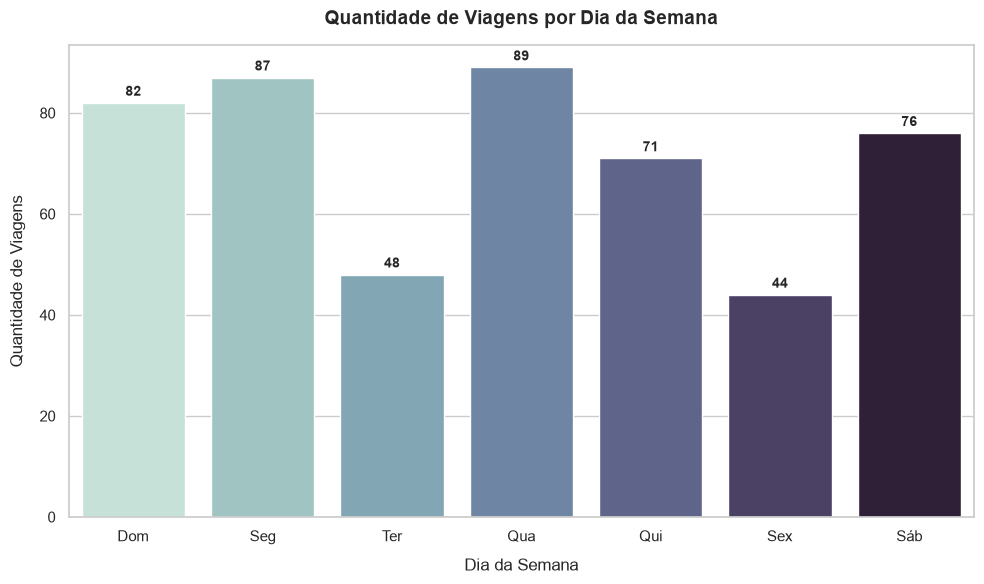

In [5]:
sns.set_theme(style='whitegrid')


df['dia_ordem'] = df['data_partida'].dt.dayofweek.apply(lambda x: (x + 1) % 7)

# Contagem de viagens (linhas) por dia da semana
df_viagens = (
    df.groupby('dia_ordem')['data_partida']
    .count()
    .reset_index(name='qtd_viagens')
)

# Nomes dos dias da semana
dias_nomes = ['Dom', 'Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb']
df_viagens['dia_nome'] = df_viagens['dia_ordem'].map(lambda x: dias_nomes[x])

# Geração de cores usando a paleta cubehelix
cores = sns.cubehelix_palette(n_colors=7, start=0.5, rot=-0.5)

# Criação do gráfico de colunas
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_viagens,
    x='dia_nome',
    y='qtd_viagens',
    palette=cores,
    hue='dia_nome',
    legend=False,
)

# Títulos e Rótulos
plt.title('Quantidade de Viagens por Dia da Semana', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Dia da Semana', fontsize=12, labelpad=10)
plt.ylabel('Quantidade de Viagens', fontsize=12, labelpad=10)

# 7. Adiciona a contagem exata no topo de cada coluna
for p in ax.patches:
    altura = int(p.get_height())
    if altura > 0:
        ax.annotate(
            f'{altura}',
            (p.get_x() + p.get_width() / 2.0, altura),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            xytext=(0, 3),
            textcoords='offset points',
        )

# Ajuste fino do layout
plt.tight_layout()
plt.show()

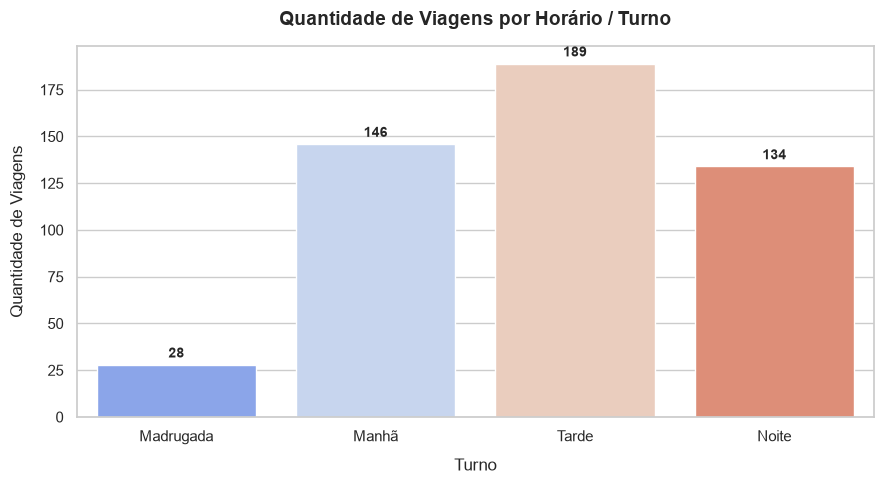

In [6]:

# Configuração de estilo do Seaborn
sns.set_theme(style='whitegrid')

# 2. Função para categorizar o horário da partida


def categorizar_turno(dt):
    # Extrai o horário no formato decimal (horas + minutos/60)
    hora_decimal = dt.hour + dt.minute / 60.0

    if 0.0 < hora_decimal <= 6.0:  # 00:01 às 06:00
        return 'Madrugada'
    elif 6.0 < hora_decimal <= 12.0:  # 06:01 às 12:00
        return 'Manhã'
    elif 12.0 < hora_decimal <= 18.0:  # 12:01 às 18:00
        return 'Tarde'
    else:  # 18:01 às 24:00 (00:00)
        return 'Noite'


df['turno'] = df['data_partida'].apply(categorizar_turno)

# Define a ordem lógica das categorias no gráfico
ordem_turnos = ['Madrugada', 'Manhã', 'Tarde', 'Noite']

# 3. Contagem de viagens por turno
df_turnos = (
    df.groupby('turno')['data_partida']
    .count()
    .reindex(ordem_turnos)
    .reset_index(name='qtd_viagens')
)

# 4. Geração da paleta de cores 'coolwarm'
cores = sns.color_palette('coolwarm', n_colors=4)

# 5. Criação do gráfico
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df_turnos,
    x='turno',
    y='qtd_viagens',
    palette=cores,
    hue='turno',
    legend=False,
)

# 6. Títulos e Rótulos
plt.title(
    'Quantidade de Viagens por Horário / Turno',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Turno', fontsize=12, labelpad=10)
plt.ylabel('Quantidade de Viagens', fontsize=12, labelpad=10)

# 7. Rótulos de contagem no topo de cada coluna
for p in ax.patches:
    altura = int(p.get_height())
    if altura > 0:
        ax.annotate(
            f'{altura}',
            (p.get_x() + p.get_width() / 2.0, altura),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            xytext=(0, 3),
            textcoords='offset points',
        )

# Ajuste fino do layout
plt.tight_layout()
plt.show()

In [7]:

# Funções auxiliares para formatação
def formatar_real(val):
    return f"{val:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

def categorizar_turno(dt):
    hora_decimal = dt.hour + dt.minute / 60.0
    if 0.0 < hora_decimal <= 6.0:
        return 'Madrugada'
    elif 6.0 < hora_decimal <= 12.0:
        return 'Manhã'
    elif 12.0 < hora_decimal <= 18.0:
        return 'Tarde'
    else:
        return 'Noite'

# Nomes em português
dias_map = {0: 'Dom', 1: 'Seg', 2: 'Ter', 3: 'Qua', 4: 'Qui', 5: 'Sex', 6: 'Sáb'}
meses_map = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

# Prepara colunas auxiliares
df['num_dia'] = df['data_partida'].dt.dayofweek.apply(lambda x: (x + 1) % 7)
df['dia_nome'] = df['num_dia'].map(dias_map)
df['turno'] = df['data_partida'].apply(categorizar_turno)

df['num_mes'] = df['data_partida'].dt.month
df['mes_nome'] = df['num_mes'].map(meses_map)

# 1. PREÇO MÉDIO E RECEITA POR DIA DA SEMANA
tabela_dia = (
    df.groupby(['num_dia', 'dia_nome'])
    .agg(
        preco_medio=('preco_unitario', 'mean'),
        receita=('receita', 'sum')
    )
    .reset_index()
    .sort_values('num_dia')
)

tabela_dia_out = pd.DataFrame({
    'Dia': tabela_dia['dia_nome'],
    'Preço médio (R$)': tabela_dia['preco_medio'].apply(formatar_real),
    'Receita (R$)': tabela_dia['receita'].apply(formatar_real)
})

print("=== PREÇO MÉDIO E RECEITA POR DIA DA SEMANA ===")
display(tabela_dia_out)


# 2. PREÇO MÉDIO E RECEITA POR TURNO
ordem_turnos = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
tabela_turno = (
    df.groupby('turno')
    .agg(
        preco_medio=('preco_unitario', 'mean'),
        receita=('receita', 'sum')
    )
    .reindex(ordem_turnos)
    .reset_index()
)

tabela_turno_out = pd.DataFrame({
    'Turno': tabela_turno['turno'],
    'Preço médio (R$)': tabela_turno['preco_medio'].apply(formatar_real),
    'Receita (R$)': tabela_turno['receita'].apply(formatar_real)
})

print("\n=== PREÇO MÉDIO E RECEITA POR TURNO ===")
display(tabela_turno_out)

# 3. PREÇO MÉDIO E RECEITA POR MÊS (Formatado Jan..Dez)
tabela_mes = (
    df.groupby(['num_mes', 'mes_nome'])
    .agg(
        preco_medio=('preco_unitario', 'mean'),
        receita=('receita', 'sum')
    )
    .reset_index()
    .sort_values('num_mes')
)

tabela_mes_out = pd.DataFrame({
    'Mês': tabela_mes['mes_nome'],
    'Preço médio (R$)': tabela_mes['preco_medio'].apply(formatar_real),
    'Receita (R$)': tabela_mes['receita'].apply(formatar_real)
})

print("\n=== PREÇO MÉDIO E RECEITA POR MÊS ===")
display(tabela_mes_out)

=== PREÇO MÉDIO E RECEITA POR DIA DA SEMANA ===


,Dia,Preço médio (R$),Receita (R$)
0,Dom,"172,40","28.795,97"
1,Seg,"180,94","31.147,64"
2,Ter,"177,26","14.881,57"
3,Qua,"216,29","36.658,89"
4,Qui,"225,58","31.092,63"
5,Sex,"189,15","15.886,18"
6,Sáb,"209,69","29.388,62"



=== PREÇO MÉDIO E RECEITA POR TURNO ===


,Turno,Preço médio (R$),Receita (R$)
0,Madrugada,"150,07","8.211,84"
1,Manhã,"180,77","53.144,56"
2,Tarde,"219,58","80.822,03"
3,Noite,"192,67","45.673,07"



=== PREÇO MÉDIO E RECEITA POR MÊS ===


,Mês,Preço médio (R$),Receita (R$)
0,Jan,"190,14","15.131,90"
1,Fev,"230,50","11.805,55"
2,Mar,"183,39","25.996,12"
3,Abr,"182,12","19.857,43"
4,Mai,"214,94","39.856,61"
5,Jun,"202,25","8.633,16"
6,Jul,"256,99","9.984,98"
7,Ago,"186,38","8.547,42"
8,Set,"234,31","4.704,44"
9,Out,"172,59","14.780,15"


In [12]:
from scipy import stats

# Agrupa por dia da semana calculando viagens e receita
df_corr = (
    df.groupby(['num_dia', 'dia_nome'])
    .agg(
        qtd_viagens=('data_partida', 'count'),
        receita_total=('receita', 'sum'),
    )
    .reset_index()
    .sort_values('num_dia')
)

# Cálculo do Coeficiente de Correlação de Pearson e p-valor
r, p_valor = stats.pearsonr(df_corr['qtd_viagens'], df_corr['receita_total'])

# Exibe a tabela de dados e os resultados estatísticos
print('=== DADOS POR DIA DA SEMANA ===')
df_exibicao = df_corr[['dia_nome', 'qtd_viagens', 'receita_total']].copy()
df_exibicao['receita_total'] = df_exibicao['receita_total'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X')
    .replace('.', ',')
    .replace('X', '.')
)
df_exibicao.columns = ['Dia', 'Qtd Viagens', 'Receita Total']
print(df_exibicao.to_string(index=False))

print('\n=== TESTE DE CORRELAÇÃO DE PEARSON ===')
print(f'Coeficiente de Correlação (r): {r:.4f}')
print(f'p-valor: {p_valor:.4e}')

if p_valor < 0.05:
  print('Resultado: Correlação estatisticamente significativa (p < 0.05).')
else:
  print(
      'Resultado: Não há evidência estatística de correlação significativa (p'
      ' >= 0.05).'
  )

=== DADOS POR DIA DA SEMANA ===
Dia  Qtd Viagens Receita Total
Dom           82  R$ 28.795,97
Seg           87  R$ 31.147,64
Ter           48  R$ 14.881,57
Qua           89  R$ 36.658,89
Qui           71  R$ 31.092,63
Sex           44  R$ 15.886,18
Sáb           76  R$ 29.388,62

=== TESTE DE CORRELAÇÃO DE PEARSON ===
Coeficiente de Correlação (r): 0.9475
p-valor: 1.1816e-03
Resultado: Correlação estatisticamente significativa (p < 0.05).


=== TESTE DE CORRELAÇÃO: PREÇO DA PASSAGEM vs. QTD DE PASSAGENS VENDIDAS ===
Pearson (linear)   : r = -0.0254 | p-valor = 5.7202e-01
Spearman (posto)   : r = -0.0183 | p-valor = 6.8423e-01

Resultado: Não há evidência estatística de correlação significativa (p >= 0.05).


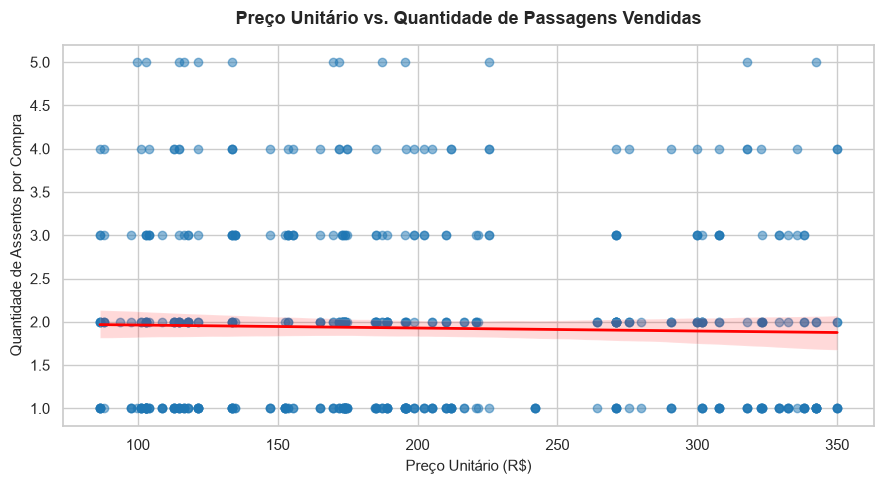

In [10]:
r_pearson, p_pearson = stats.pearsonr(df['preco_unitario'], df['quantidade_assentos'])
r_spearman, p_spearman = stats.spearmanr(df['preco_unitario'], df['quantidade_assentos'])

# 4. Exibição dos Resultados no Terminal
print("=== TESTE DE CORRELAÇÃO: PREÇO DA PASSAGEM vs. QTD DE PASSAGENS VENDIDAS ===")
print(f"Pearson (linear)   : r = {r_pearson:.4f} | p-valor = {p_pearson:.4e}")
print(f"Spearman (posto)   : r = {r_spearman:.4f} | p-valor = {p_spearman:.4e}")

if p_pearson < 0.05:
    print("\nResultado: Há uma correlação estatisticamente significativa (p < 0.05).")
else:
    print("\nResultado: Não há evidência estatística de correlação significativa (p >= 0.05).")

# 5. Visualização Gráfica (Scatter Plot + Regressão)
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.regplot(
    data=df,
    x='preco_unitario',
    y='quantidade_assentos',
    scatter_kws={'alpha': 0.5, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Preço Unitário vs. Quantidade de Passagens Vendidas', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Preço Unitário (R$)', fontsize=11)
plt.ylabel('Quantidade de Assentos por Compra', fontsize=11)

plt.tight_layout()
plt.show()